# Data Cleaning and EDA with Time Series Data
This notebook holds Assignment 2.1 for Module 2 in AAI 530, Data Analytics and the Internet of Things.

In this assignment, you will go through some basic data cleaning and exploratory analysis steps on a real IoT dataset. Much of what we'll be doing should look familiar from Module 2's lab session, but Google will be your friend on the parts that are new.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

One sign of mature code is conforming to a style guide. We recommend the [Google Python Style Guide](https://google.github.io/styleguide/pyguide.html). If you use a different style guide, please include a cell with a link.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential `import` statements and make sure that all such statements are moved into the designated cell.

When you save your notebook as a pdf, make sure that all cell output is visible (even error messages) as this will aid your instructor in grading your work.

Make use of non-code cells for written commentary. These cells should be grammatical and clearly written. In some of these cells you will have questions to answer. The questions will be marked by a "Q:" and will have a corresponding "A:" spot for you. *Make sure to answer every question marked with a `Q:` for full credit.*


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load and clean your data
The household electric consumption dataset can be downloaded as a zip file here along with a description of the data attributes:
https://archive.ics.uci.edu/ml/datasets/Individual+household+electric+power+consumption#

First we will load this data into a pandas df and do some initial discovery

In [3]:
df_raw = pd.read_csv("/content/household_power_consumption.txt", delimiter = ";")

/tmp/ipython-input-2934897524.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("/content/household_power_consumption.txt", delimiter = ";")


In [4]:
df_raw.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [5]:
df_raw.describe()

,Sub_metering_3
count,1.636453e+06
mean,6.329037e+00
std,8.387870e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


Well that's not what we want to see--why is only one column showing up?
Let's check the datatypes

In [6]:
df_raw.dtypes

,0
Date,object
Time,object
Global_active_power,object
Global_reactive_power,object
Voltage,object
Global_intensity,object
Sub_metering_1,object
Sub_metering_2,object
Sub_metering_3,float64


OK, so only one of our columns came in as the correct data type. We'll get to why that is later, but first let's get everything assigned correctly so that we can use our describe function.

combine the 'Date' and 'Time' columns into a column called 'Datetime' and convert it into a datetime datatype. Heads up, the date is not in the standard format...**

use the pd.to_numeric function to convert the rest of the columns. You'll need to decide what to do with your errors for the cells that don't convert to numbers**

In [7]:
#make a copy of the raw data so that we can go back and refer to it later
df = df_raw.copy()


In [8]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

In [9]:
for col in ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Let's use the Datetime column to turn the Date and Time columns into date and time dtypes.

In [10]:
df['Date'] = df['Datetime'].dt.date
df['Time'] = df['Datetime'].dt.time

In [11]:
df.dtypes

,0
Date,object
Time,object
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64
Datetime,datetime64[ns]


It looks like our Date and Time columns are still of type "object", but in that case that's because the pandas dtypes function doesn't recognize all data types. We can check this by printing out the first value of each column directly.

In [12]:
df.Date[0]

datetime.date(2006, 12, 16)

In [13]:
df.Time[0]

datetime.time(17, 24)

Now that we've got the data in the right datatypes, let's take a look at the describe() results

In [14]:
desc = df.describe()

#force the printout not to use scientific notation
desc[desc.columns[:-1]] = desc[desc.columns[:-1]].apply(lambda x: x.apply("{0:.4f}".format))
desc

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,1636454.0000,1636454.0000,1636453.0000,1636453.0000,1636453.0000,1636453.0000,1636453.0000,1647935
mean,1.1092,0.1221,240.7223,4.7046,1.1625,1.3532,6.3290,2008-07-10 22:10:59.999996160
min,0.0760,0.0000,223.2000,0.2000,0.0000,0.0000,0.0000,2006-12-16 17:24:00
25%,0.3020,0.0460,238.7800,1.4000,0.0000,0.0000,0.0000,2007-09-28 19:47:30
50%,0.5920,0.1000,240.9000,2.6000,0.0000,0.0000,1.0000,2008-07-10 22:11:00
75%,1.5460,0.1920,242.8600,6.4000,0.0000,1.0000,17.0000,2009-04-23 00:34:30
max,11.1220,1.3900,254.1500,48.4000,84.0000,78.0000,31.0000,2010-02-03 02:58:00
std,1.0926,0.1121,3.3471,4.5935,6.2953,6.0181,8.3879,NaN


Those row counts look a little funky. Let's visualize our missing data.

<Axes: >

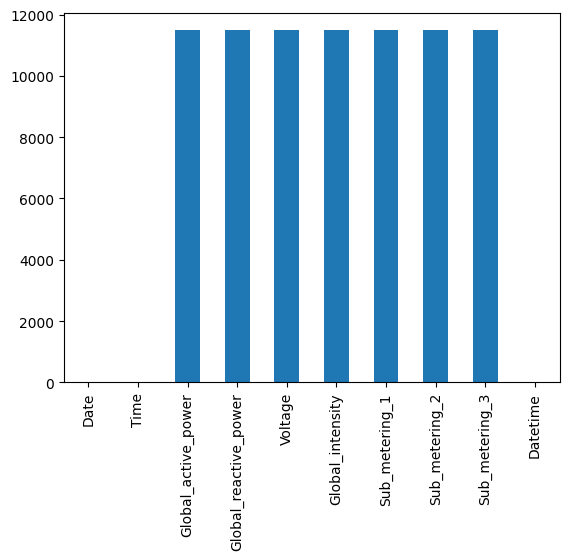

In [15]:
df.isna().sum().plot.bar()

(array([13514., 13634., 13757., 13879., 14000., 14123., 14245., 14365.,
        14488., 14610.]),
 [Text(13514.0, 0, '2007-01'),
  Text(13634.0, 0, '2007-05'),
  Text(13757.0, 0, '2007-09'),
  Text(13879.0, 0, '2008-01'),
  Text(14000.0, 0, '2008-05'),
  Text(14123.0, 0, '2008-09'),
  Text(14245.0, 0, '2009-01'),
  Text(14365.0, 0, '2009-05'),
  Text(14488.0, 0, '2009-09'),
  Text(14610.0, 0, '2010-01')])

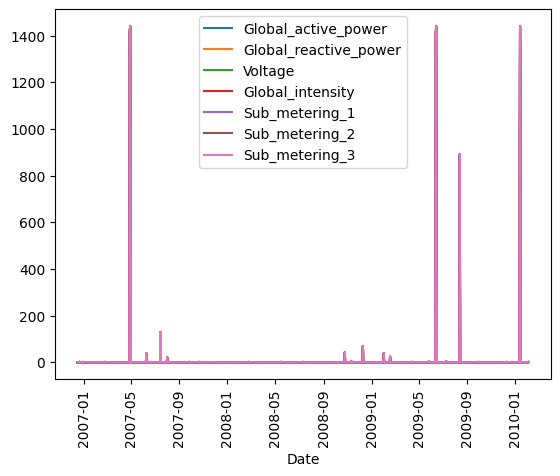

In [22]:
#https://stackoverflow.com/questions/53947196/groupby-class-and-count-missing-values-in-features
df_na = df.drop('Date', axis = 1).isna().groupby(df.Date, sort = False).sum().reset_index()
df_na.plot(x='Date', y=df_na.columns[2:-1])
plt.xticks(rotation=90)

**Q: What do you notice about the pattern of missing data?**

A: The fact that the lines are overlapping, and  only one line was clearly visible, strongly suggests that when data is missing, it's typically missing across multiple related columns simultaneously. This indicates that the missingness is likely not due to isolated sensor failures, but rather to a common underlying cause affecting the data collection system as a whole. No Obvious Seasonal Pattern

**Q: What method makes the most sense to you for dealing with our missing data and why? (There isn't necessarily a single right answer here)**

A: For this time series dataset, linear interpolation makes the most sense as a first step for handling missing data. Unlike simple imputation methods (like mean/median) which ignore temporal order, linear interpolation estimates missing values based on the values before and after them. It creates a smooth transition between valid data points


In [23]:
#clean up missing data here
df.interpolate(method='linear', inplace=True)

/tmp/ipython-input-1709007023.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True)


In [29]:
desc = df.describe()
#force the printout not to use scientific notation
desc[desc.columns[:-1]] = desc[desc.columns[:-1]].apply(lambda x: x.apply("{0:.4f}".format))
desc

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,1647935.0000,1647935.0000,1647935.0000,1647935.0000,1647935.0000,1647935.0000,1647935.0000,1647935
mean,1.1087,0.1222,240.7175,4.7016,1.1564,1.3469,6.3313,2008-07-10 22:10:59.999996160
min,0.0760,0.0000,223.2000,0.2000,0.0000,0.0000,0.0000,2006-12-16 17:24:00
25%,0.3040,0.0460,238.7700,1.4000,0.0000,0.0000,0.0000,2007-09-28 19:47:30
50%,0.5940,0.1000,240.9000,2.6000,0.0000,0.0000,1.0000,2008-07-10 22:11:00
75%,1.5480,0.1920,242.8600,6.4000,0.0000,1.0000,17.0000,2009-04-23 00:34:30
max,11.1220,1.3900,254.1500,48.4000,84.0000,78.0000,31.0000,2010-02-03 02:58:00
std,1.0903,0.1118,3.3513,4.5833,6.2742,5.9980,8.3819,NaN


Great! As we can see from the describe() output, the count for all the numerical columns is now the same. This confirms that the missing values have been successfully filled using linear interpolation.

## Visualizing the data

We're working with time series data, so visualizing the data over time can be helpful in identifying possible patterns or metrics that should be explored with further analysis and machine learning methods.


**Q: Which variables did you choose and why do you think they might be interesting to compare to each other over time? Remember that data descriptions are available at the data source link at the top of the assignment.**

A: I chose Global_active_power, Voltage, Global_intensity, and Sub_metering_1.

*   Global_active_power: This is the total active power consumed by the household (in kilowatts). It's a primary indicator of overall energy usage and will show the general demand patterns.
*   Voltage: This refers to the electric potential (in volts). It's important to monitor for stability and potential fluctuations that could impact appliances or indicate grid issues.
*   Global_intensity: This is the electrical current (in amperes). It's directly related to power consumption (Power = Voltage * Current) and can show how much current the household is drawing.
*   Sub_metering_1: This represents the energy consumption of the kitchen, primarily a dishwasher, an oven, and a microwave (in Watt-hours). This allows for a more granular look at specific appliance usage and how it contributes to the overall active power.

I believe these variables are interesting to compare because they represent different facets of electrical usage and supply. `Global_active_power` and `Global_intensity` are directly related and show the overall load. `Voltage` shows the stability of the supply. `Sub_metering_1` offers insight into a specific area's consumption, allowing us to see how individual components contribute to the total. Comparing their trends can reveal how daily routines, seasonal changes, or even specific appliance usage affect the overall electrical profile of the household.

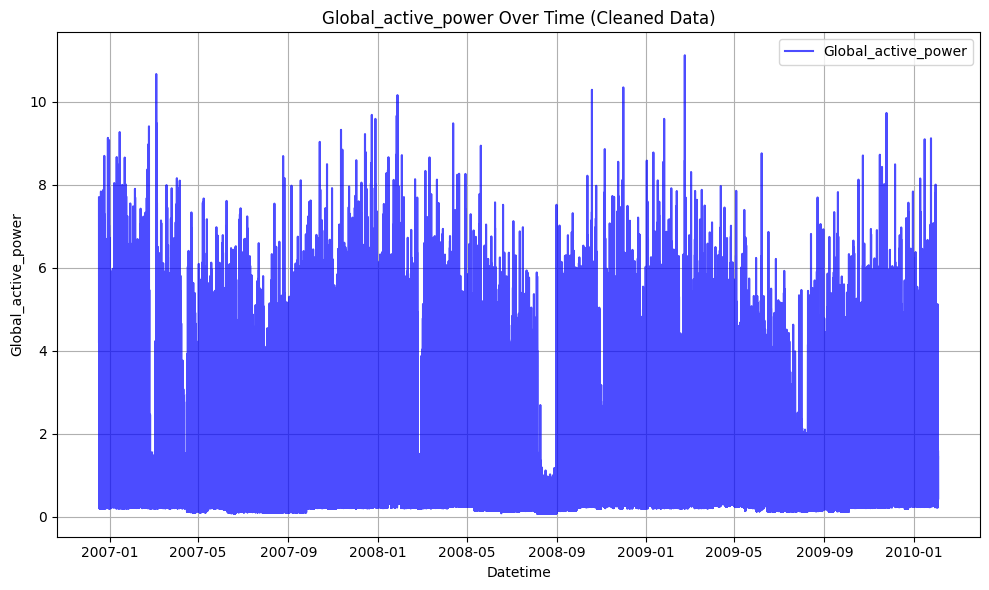

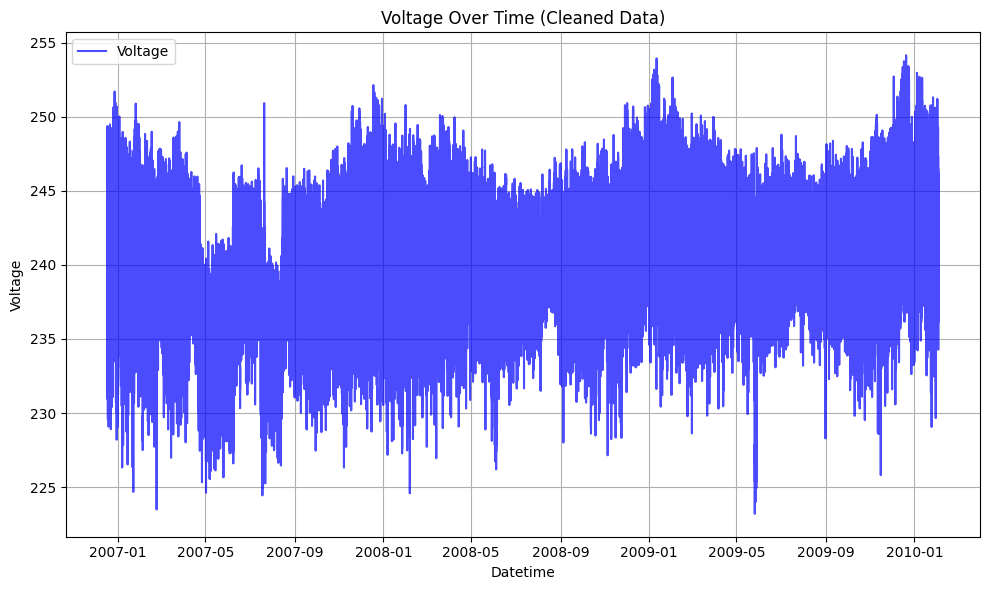

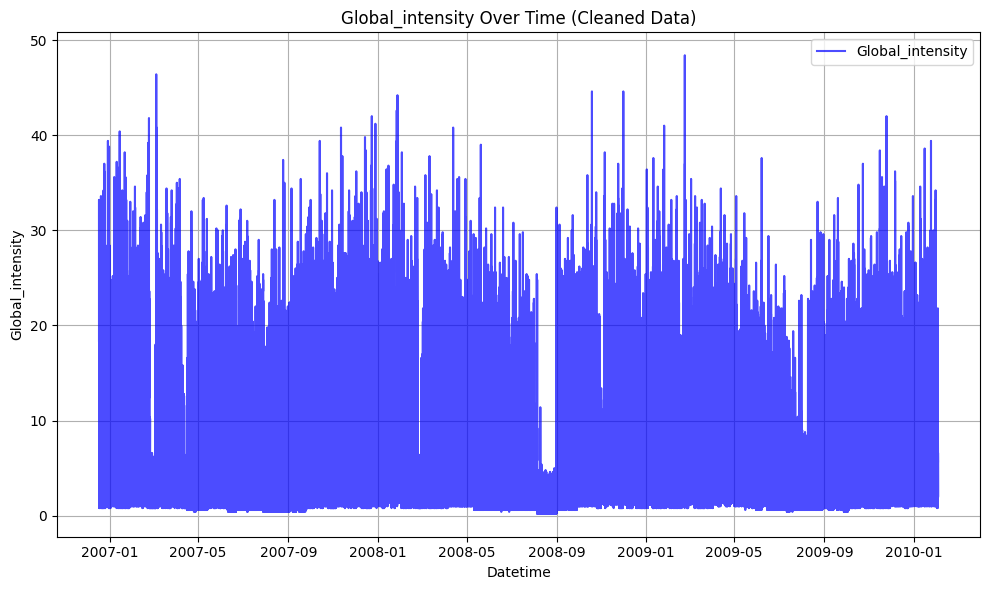

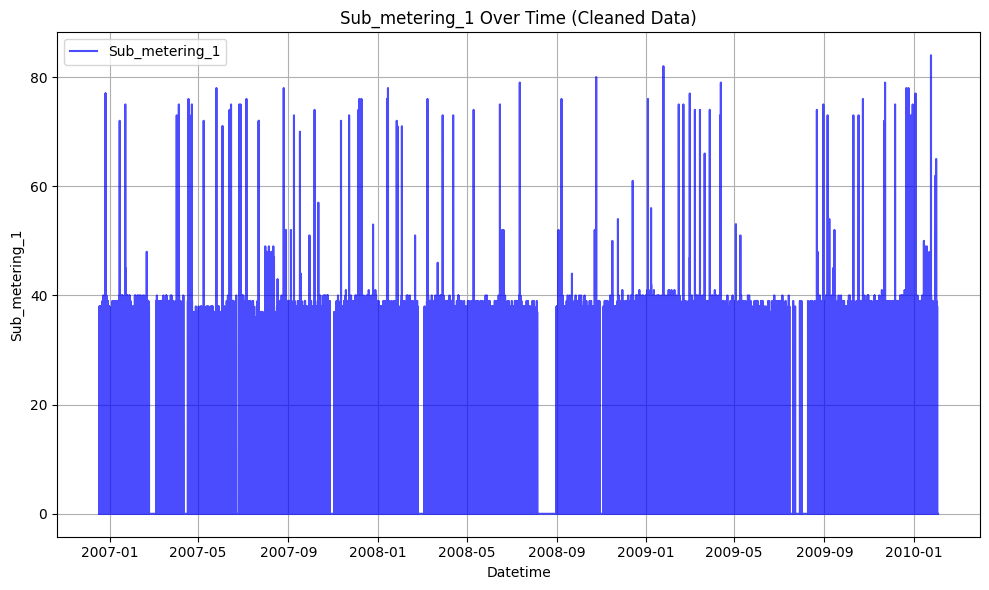

In [33]:
#build your line chart here

import matplotlib.pyplot as plt

# Choose four variables to visualize
chosen_vars = ['Global_active_power', 'Voltage', 'Global_intensity', 'Sub_metering_1']

# Create separate line charts for each variable
for var in chosen_vars:
    plt.figure(figsize=(10, 6))
    plt.plot(df['Datetime'], df[var], label=var, color='blue', alpha=0.7)
    plt.title(f'{var} Over Time (Cleaned Data)')
    plt.xlabel('Datetime')
    plt.ylabel(var)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


**Q: What do you notice about visualizing the raw data? Is this a useful visualization? Why or why not?**

A:  The overall picture is highly discontinuous. It would be very difficult to discern overall trends, cyclical patterns, or long-term behavior due to the frequent interruptions. For the purpose of understanding the actual electricity consumption patterns, voltage stability, or intensity variations over time, visualizing the raw data directly is not very useful. The missing pieces make it impossible to get a coherent and accurate representation of the phenomena being measured. It would be misleading to draw conclusions about trends from such an incomplete picture.

**Compute a monthly average for the data and plot that data in the same style as above. You should have one average per month and year (so June 2007 is separate from June 2008).**

In [36]:
#compute your monthly average here

# Set 'Datetime' as the index for resampling
df_monthly = df.set_index('Datetime')

# Compute monthly average for numerical columns, excluding non-numeric ones like 'Date' and 'Time'
df_monthly_avg = df_monthly.drop(columns=['Date', 'Time']).resample('M').mean().reset_index()

/tmp/ipython-input-2519632885.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_avg = df_monthly.drop(columns=['Date', 'Time']).resample('M').mean().reset_index()


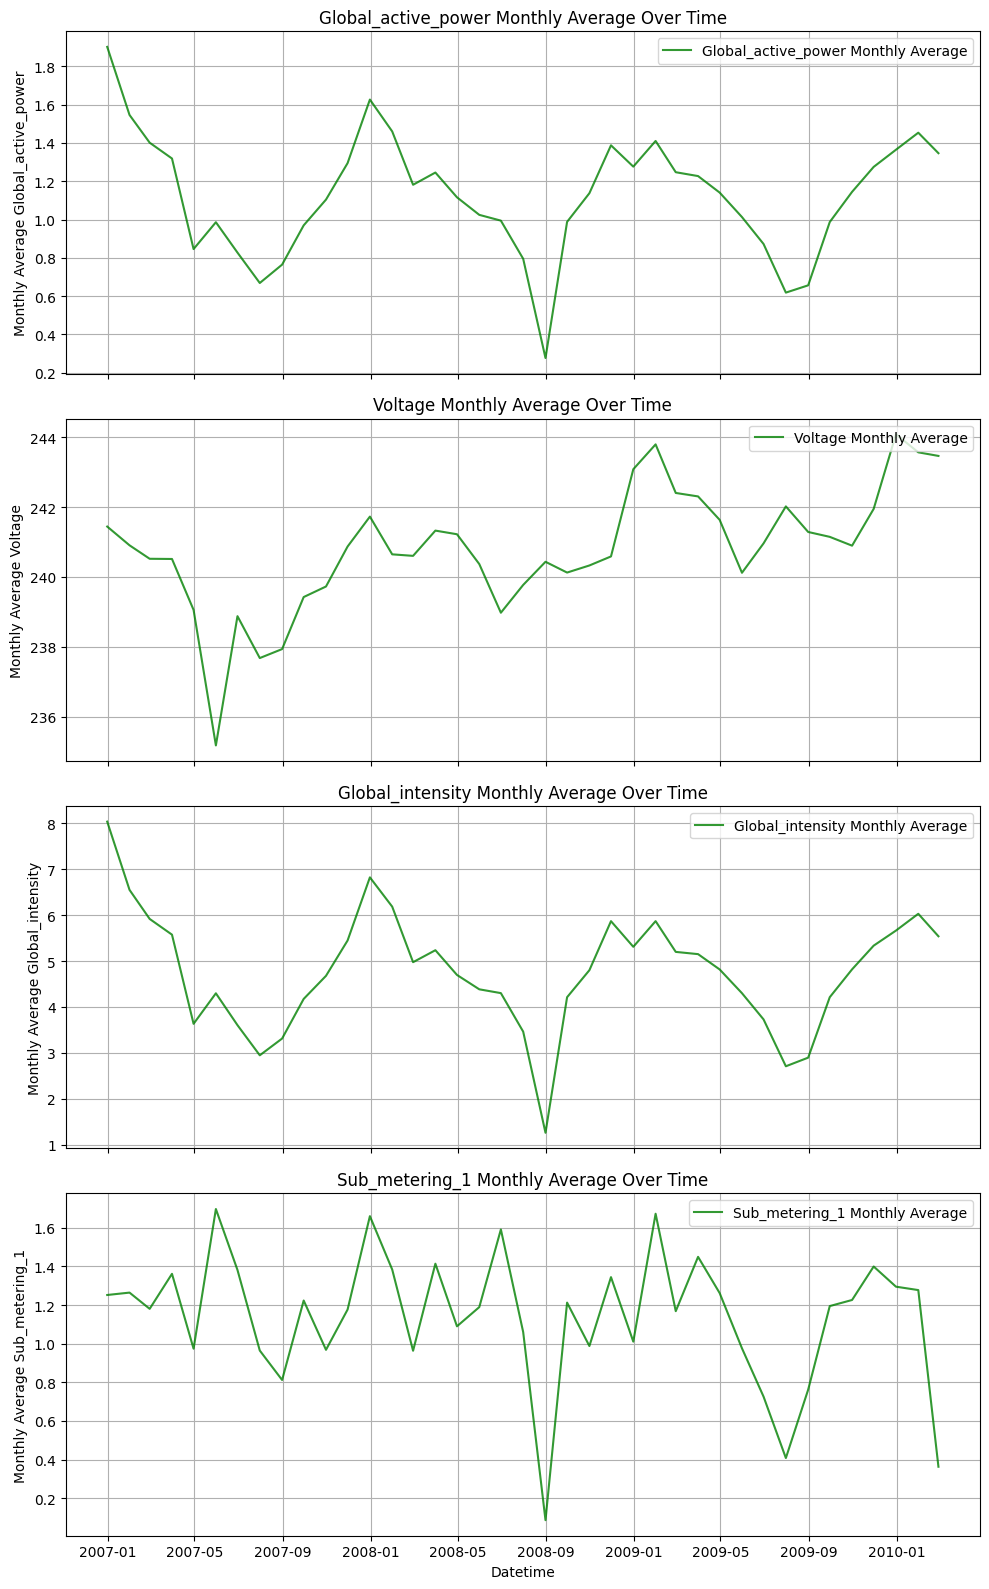

In [40]:
#build your linechart here

import matplotlib.pyplot as plt

# Choose the same four variables as before to visualize
chosen_vars = ['Global_active_power', 'Voltage', 'Global_intensity', 'Sub_metering_1']

# Create subplots for each variable
fig, axes = plt.subplots(nrows=len(chosen_vars), ncols=1, figsize=(10, 4 * len(chosen_vars)), sharex=True)

for i, var in enumerate(chosen_vars):
    axes[i].plot(df_monthly_avg['Datetime'], df_monthly_avg[var], label=f'{var} Monthly Average', color='green', alpha=0.8)
    axes[i].set_title(f'{var} Monthly Average Over Time')
    axes[i].set_ylabel(f'Monthly Average {var}')
    axes[i].grid(True)
    axes[i].legend(loc='upper right')

# Set common x-label for the bottom subplot
axes[-1].set_xlabel('Datetime')

plt.tight_layout()
plt.show()

**Q: What patterns do you see in the monthly data? Do any of the variables seem to move together?**

A: Global_active_power, Global_intensity and Sub_metering_1  move together, as they are directly related measures of electricity consumption

** Now compute a 30-day moving average on the original data and visualize it in the same style as above. Hint: If you use the rolling() function, be sure to consider the resolution of our data.**

In [41]:
#compute your moving average here

# Set 'Datetime' as the index for time-based rolling window calculation
df_indexed = df.set_index('Datetime')

# Define the window size for a 30-day moving average
# '30D' is a pandas frequency string for 30 days
window_size = '30D'

# Choose the same four variables for which we calculated monthly averages
chosen_vars = ['Global_active_power', 'Voltage', 'Global_intensity', 'Sub_metering_1']

# Compute the 30-day moving average for these variables
df_rolling_avg = df_indexed[chosen_vars].rolling(window=window_size).mean().reset_index()

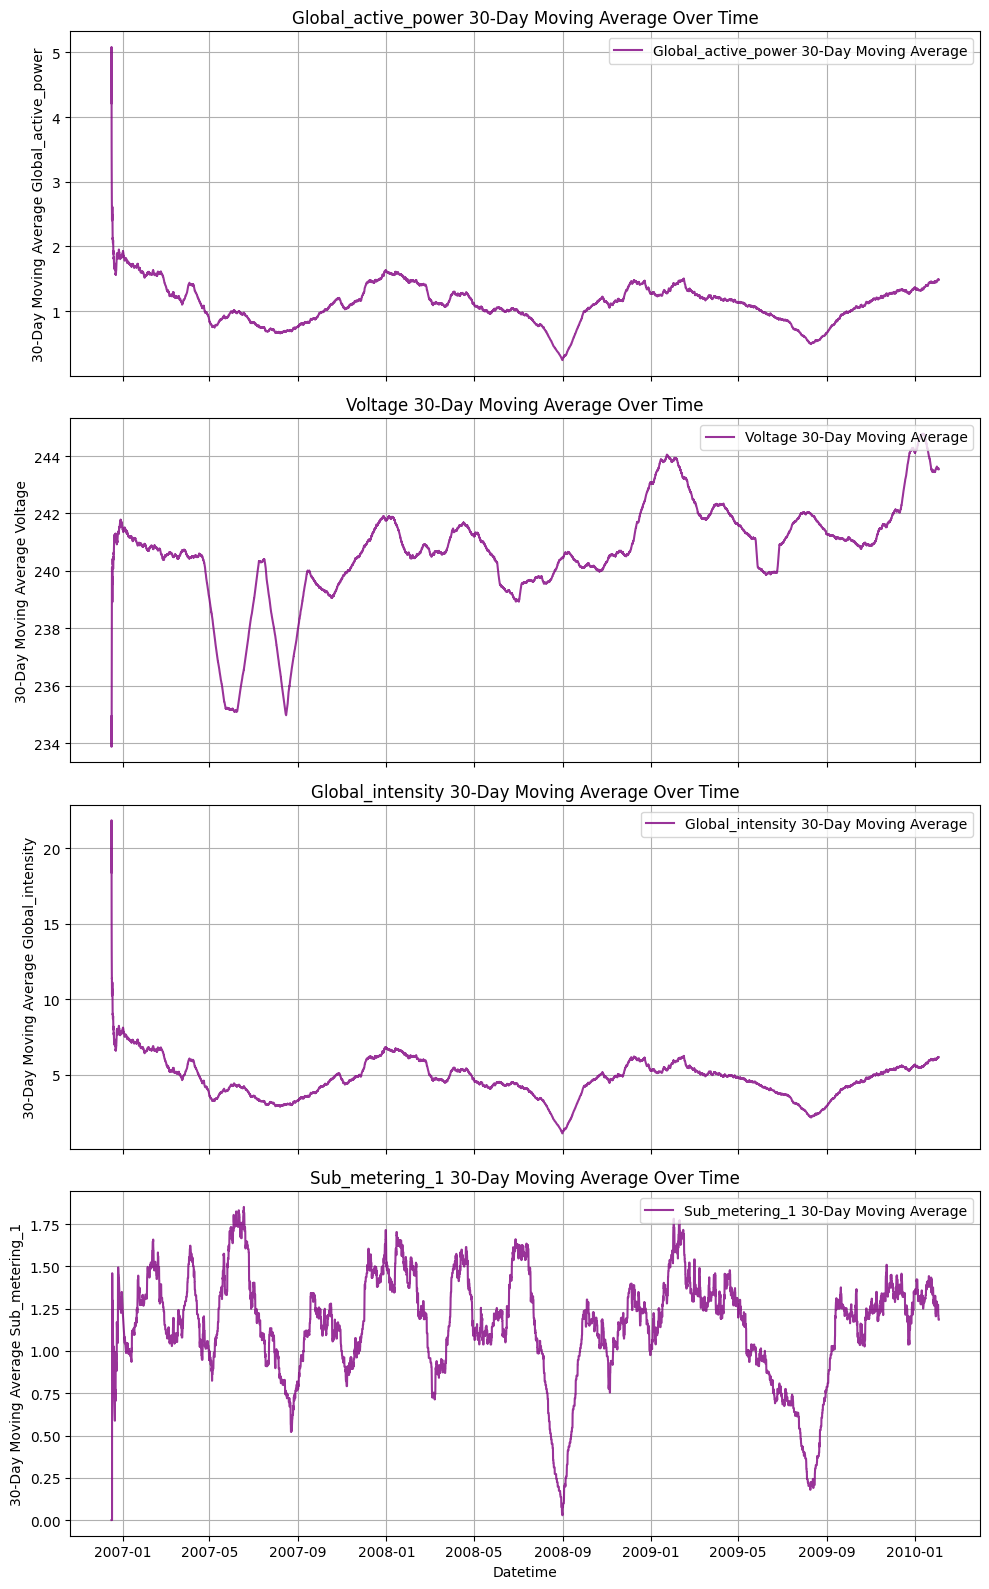

In [43]:
#build your line chart on the moving average here

import matplotlib.pyplot as plt

# Choose the same four variables as before to visualize
chosen_vars = ['Global_active_power', 'Voltage', 'Global_intensity', 'Sub_metering_1']

# Create subplots for each variable
fig, axes = plt.subplots(nrows=len(chosen_vars), ncols=1, figsize=(10, 4 * len(chosen_vars)), sharex=True)

for i, var in enumerate(chosen_vars):
    axes[i].plot(df_rolling_avg['Datetime'], df_rolling_avg[var], label=f'{var} 30-Day Moving Average', color='purple', alpha=0.8)
    axes[i].set_title(f'{var} 30-Day Moving Average Over Time')
    axes[i].set_ylabel(f'30-Day Moving Average {var}')
    axes[i].grid(True)
    axes[i].legend(loc='upper right')

# Set common x-label for the bottom subplot
axes[-1].set_xlabel('Datetime')

plt.tight_layout()
plt.show()

**Q: How does the moving average compare to the monthly average? Which is a more effective way to visualize this data and why?**

A: Monthly Average provides a highly smoothed view of the data. It's excellent for identifying long-term trends and seasonality (e.g., if consumption is generally higher in winter than summer) by completely removing short-term noise and daily fluctuations.

While moving average offers a more granular smoothing compared to the monthly average. It still smooths out daily and weekly variations but retains more detail about shifts and patterns that occur over a few weeks. It reacts more quickly to changes in trend than the monthly average but is smoother than the raw daily data.
## Data Covariance and Correlation

Let's take a look at the Correlation Matrix for the four global power variables in the dataset.

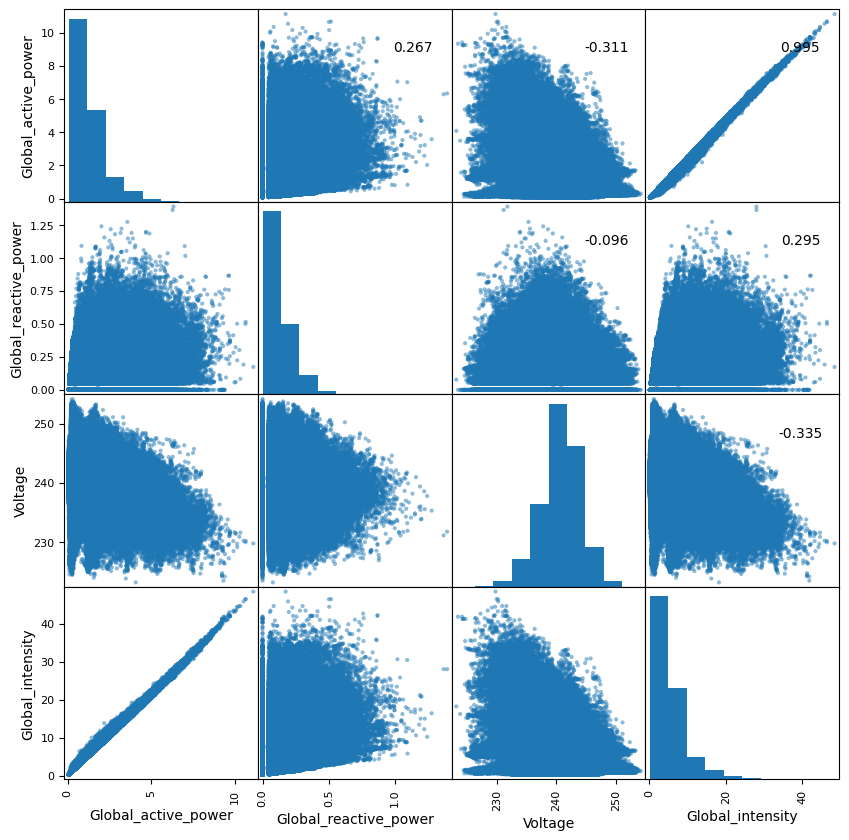

In [44]:
axes = pd.plotting.scatter_matrix(df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']], alpha=0.5,figsize = [10,10])
corr = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']].corr(method = 'spearman').to_numpy() #nonlinear
for i, j in zip(*plt.np.triu_indices_from(axes, k=1)):
    axes[i, j].annotate("%.3f" %corr[i,j], (0.8, 0.8), xycoords='axes fraction', ha='center', va='center')
plt.show()

**Q: Describe any patterns and correlations that you see in the data. What effect does this have on how we use this data in downstream tasks?**

A: There is a near-perfect positive correlation((0.995)) between Global_active_power and Global_intensity. This makes physical sense because Power is the product of Voltage and Current (Intensity). Since Voltage is relatively stable (around 240V), any increase in current directly results in a proportional increase in active power. Voltage shows a weak negative correlation with both Global_active_power (-0.311) and Global_intensity (-0.335). This is often due to the voltage tends to drop slightly due to resistance in the lines.

The near-perfect correlation between Global_active_power and Global_intensity indicates multicollinearity. Including both of these highly correlated variables can be problematic. It can make the model unstable and make it difficult to determine the importance of each individual feature.

Because they carry almost the exact same information, we should likely exclude one of them (e.g., drop Global_intensity) during feature selection. This simplifies the model, reduces training time, and avoids the issues associated with multicollinearity without losing valuable information.

